# Comparative Analysis of Machine Learning Algorithms for Fake News Detection


**Warning: this notebook is computationally heavy and may take 30-90+ minutes to run completely. Let it run in the background rather than interrupting it.**

## STEP 1: Import Basic Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import os

sns.set(style="darkgrid")

# create a folder to save all figures into, for easy insertion into the thesis document
os.makedirs("figures", exist_ok=True)

print("Step 1 complete: basic libraries imported, figures/ folder ready")

Step 1 complete: basic libraries imported, figures/ folder ready


## STEP 2: Import Machine Learning Tools

In [23]:
from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_validate, cross_val_predict
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    log_loss, brier_score_loss, mean_squared_error
)

print("Step 2 complete: all scikit-learn tools imported")

Step 2 complete: all scikit-learn tools imported


## STEP 3: Load the Dataset

In [24]:
if os.path.exists("data/Fake.csv") and os.path.exists("data/True.csv"):
    fake_df = pd.read_csv("data/Fake.csv")
    true_df = pd.read_csv("data/True.csv")
    fake_df["label"] = 0
    true_df["label"] = 1
    print("Fake news articles:", fake_df.shape)
    print("Real news articles:", true_df.shape)
    df = pd.concat([fake_df, true_df], axis=0)
    df["content"] = df["title"].astype(str) + " " + df["text"].astype(str)
    df = df[["content", "label"]]
elif os.path.exists("data/fake_or_real_news.csv"):
    raw = pd.read_csv("data/fake_or_real_news.csv")
    raw["label"] = raw["label"].map({"FAKE": 0, "REAL": 1})
    raw["content"] = raw["title"].astype(str) + " " + raw["text"].astype(str)
    df = raw[["content", "label"]]
else:
    raise FileNotFoundError("Put Fake.csv+True.csv or fake_or_real_news.csv in data/ folder.")

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("\nCombined dataset shape:", df.shape)
print(df["label"].value_counts())
df.head()

Fake news articles: (23481, 5)
Real news articles: (21417, 5)

Combined dataset shape: (44898, 2)
label
0    23481
1    21417
Name: count, dtype: int64


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


## STEP 4: Visualize Class Distribution (Figure 3.2)

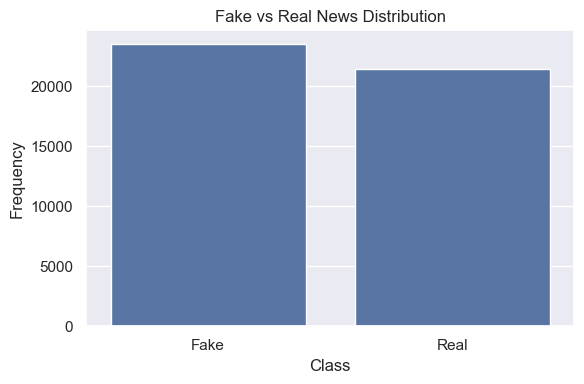

Saved: figures/fig_3_2_class_distribution.png


In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.xticks([0,1], ["Fake","Real"])
plt.title("Fake vs Real News Distribution")
plt.xlabel("Class"); plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/fig_3_2_class_distribution.png", dpi=300)
plt.show()
print("Saved: figures/fig_3_2_class_distribution.png")

## STEP 5: Remove Source Artifacts, Then Clean the Text
Bias-aware preprocessing: strips publisher signatures like "WASHINGTON (Reuters) -" before general text cleaning.

In [26]:
def remove_source_artifacts(text):
    text = str(text)
    text = re.sub(r"\b[A-Z][A-Za-z\s]*\(Reuters\)\s*-+\s*", "", text)
    text = re.sub(r"\(Reuters\)", "", text)
    text = re.sub(r"\b[A-Z][A-Za-z\s]*\(AP\)\s*-+\s*", "", text)
    text = re.sub(r"\(AP\)", "", text)
    return text

df["content_debiased"] = df["content"].apply(remove_source_artifacts)
reuters_count = df["content"].str.contains(r"\(Reuters\)", regex=True).sum()
print(f"Articles that originally contained '(Reuters)': {reuters_count} out of {len(df)}")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_content"] = df["content_debiased"].apply(clean_text)
print("\nSample cleaned (debiased) text:")
print(df["clean_content"].iloc[0][:300])

Articles that originally contained '(Reuters)': 21256 out of 44898

Sample cleaned (debiased) text:
ben stein calls out th circuit court committed a ‘coup d’état’ against the constitution st century wire says ben stein reputable professor from pepperdine university also of some hollywood fame appearing in tv shows and films such as ferris bueller s day off made some provocative statements on judge


---
## ANALYSIS 1: BASELINE (TF-IDF Word Features Only)

STEP 6: Convert Text to Numbers (TF-IDF)

In [27]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X = tfidf.fit_transform(df["clean_content"])
y = df["label"]
print("TF-IDF feature matrix shape:", X.shape)

TF-IDF feature matrix shape: (44898, 5000)


Step 7: Baseline Model Training & Evaluation (TF-IDF Features Only)

In this step, we evaluate five baseline classifiers (Logistic Regression, Naive Bayes, Random Forest, Linear SVC, and Passive Aggressive Classifier) trained **strictly on the 5,000 TF-IDF features** ($X$). 

Each model undergoes fast hyperparameter tuning (`RandomizedSearchCV`, $k=3$) followed by **5-fold Stratified Cross-Validation** (`StratifiedKFold`, $k=5$). Overfitting is evaluated across all folds by tracking the generalization performance gap ($\text{Gap} = \text{Train Acc} - \text{Test Acc}$).

In [28]:
# ==============================================================================
# STEP 7A: BASELINE EVALUATION ON BASIC TF-IDF FEATURES ONLY
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Ensure sparse TF-IDF matrix is in CSR format for efficient slicing
X = X.tocsr()

# Define baseline models with standard default configurations
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "SVM": LinearSVC(max_iter=2000, dual="auto", random_state=42),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
}

print("=== STAGE 1: EVALUATING BASELINE MODELS ON BASIC TF-IDF FEATURES ===")
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tfidf_results = {}

for name, model in base_models.items():
    print(f"Evaluating baseline {name}...")
    
    # 5-Fold Stratified Cross-Validation
    scores = cross_validate(
        model, X, y, cv=cv5,
        scoring=["accuracy", "f1", "precision", "recall"],
        return_train_score=True, n_jobs=1
    )

    train_acc = scores["train_accuracy"].mean() * 100
    test_acc = scores["test_accuracy"].mean() * 100
    gap = round(train_acc - test_acc, 2)
    verdict = "Possible OVERFITTING" if gap > 5 else ("Possible UNDERFITTING" if test_acc < 80 else "Good fit")

    tfidf_results[name] = {
        "Accuracy": round(test_acc, 2),
        "F1 Score": round(scores["test_f1"].mean() * 100, 2),
        "Precision": round(scores["test_precision"].mean() * 100, 2),
        "Recall": round(scores["test_recall"].mean() * 100, 2),
        "Train Acc": round(train_acc, 2),
        "Gap": gap,
        "Verdict": verdict
    }

tfidf_df = pd.DataFrame(tfidf_results).T
print("\n=== BASIC TF-IDF BASELINE RESULTS (5-Fold CV) ===")
print(tfidf_df)

=== STAGE 1: EVALUATING BASELINE MODELS ON BASIC TF-IDF FEATURES ===
Evaluating baseline Logistic Regression...
Evaluating baseline Naive Bayes...
Evaluating baseline Random Forest...
Evaluating baseline SVM...
Evaluating baseline Passive Aggressive...

=== BASIC TF-IDF BASELINE RESULTS (5-Fold CV) ===
                    Accuracy F1 Score Precision Recall Train Acc   Gap  \
Logistic Regression    98.04    97.96     97.67  98.24      98.6  0.56   
Naive Bayes            92.62     92.2     92.96  91.45     92.84  0.22   
Random Forest          98.52    98.45      98.5  98.39     100.0  1.48   
SVM                    98.72    98.66     98.73  98.59     99.74  1.01   
Passive Aggressive     98.53    98.46      98.6  98.32     100.0  1.46   

                      Verdict  
Logistic Regression  Good fit  
Naive Bayes          Good fit  
Random Forest        Good fit  
SVM                  Good fit  
Passive Aggressive   Good fit  


Section 8 Baseline Evaluation & Visualizations

This section presents the performance of five baseline machine learning classifiers (**Logistic Regression**, **Multinomial Naive Bayes**, **Random Forest**, **Linear SVM**, and **Passive Aggressive Classifier**) evaluated using **5-Fold Stratified Cross-Validation** on basic TF-IDF features.

Figure 1: Model Accuracy Comparison

Figure 2: Performance Metrics Breakdown

Figure 3: Generalization Gap (Train vs. Test Accuracy)

Figure 4: Confusion Matrix (Linear SVM)


       Classifier Model  Accuracy (%)  F1 Score (%)  Precision (%)  Recall (%)  Train Accuracy (%) Gap (%)  Verdict
    Logistic Regression         98.04         97.96          97.67       98.24               98.60   +0.56 Good fit
             Linear SVM         98.72         98.66          98.73       98.59               99.74   +1.01 Good fit
     Passive Aggressive         98.53         98.46          98.60       98.32              100.00   +1.46 Good fit
Multinomial Naive Bayes         92.62         92.20          92.96       91.45               92.84   +0.22 Good fit
          Random Forest         98.52         98.45          98.50       98.39              100.00   +1.48 Good fit


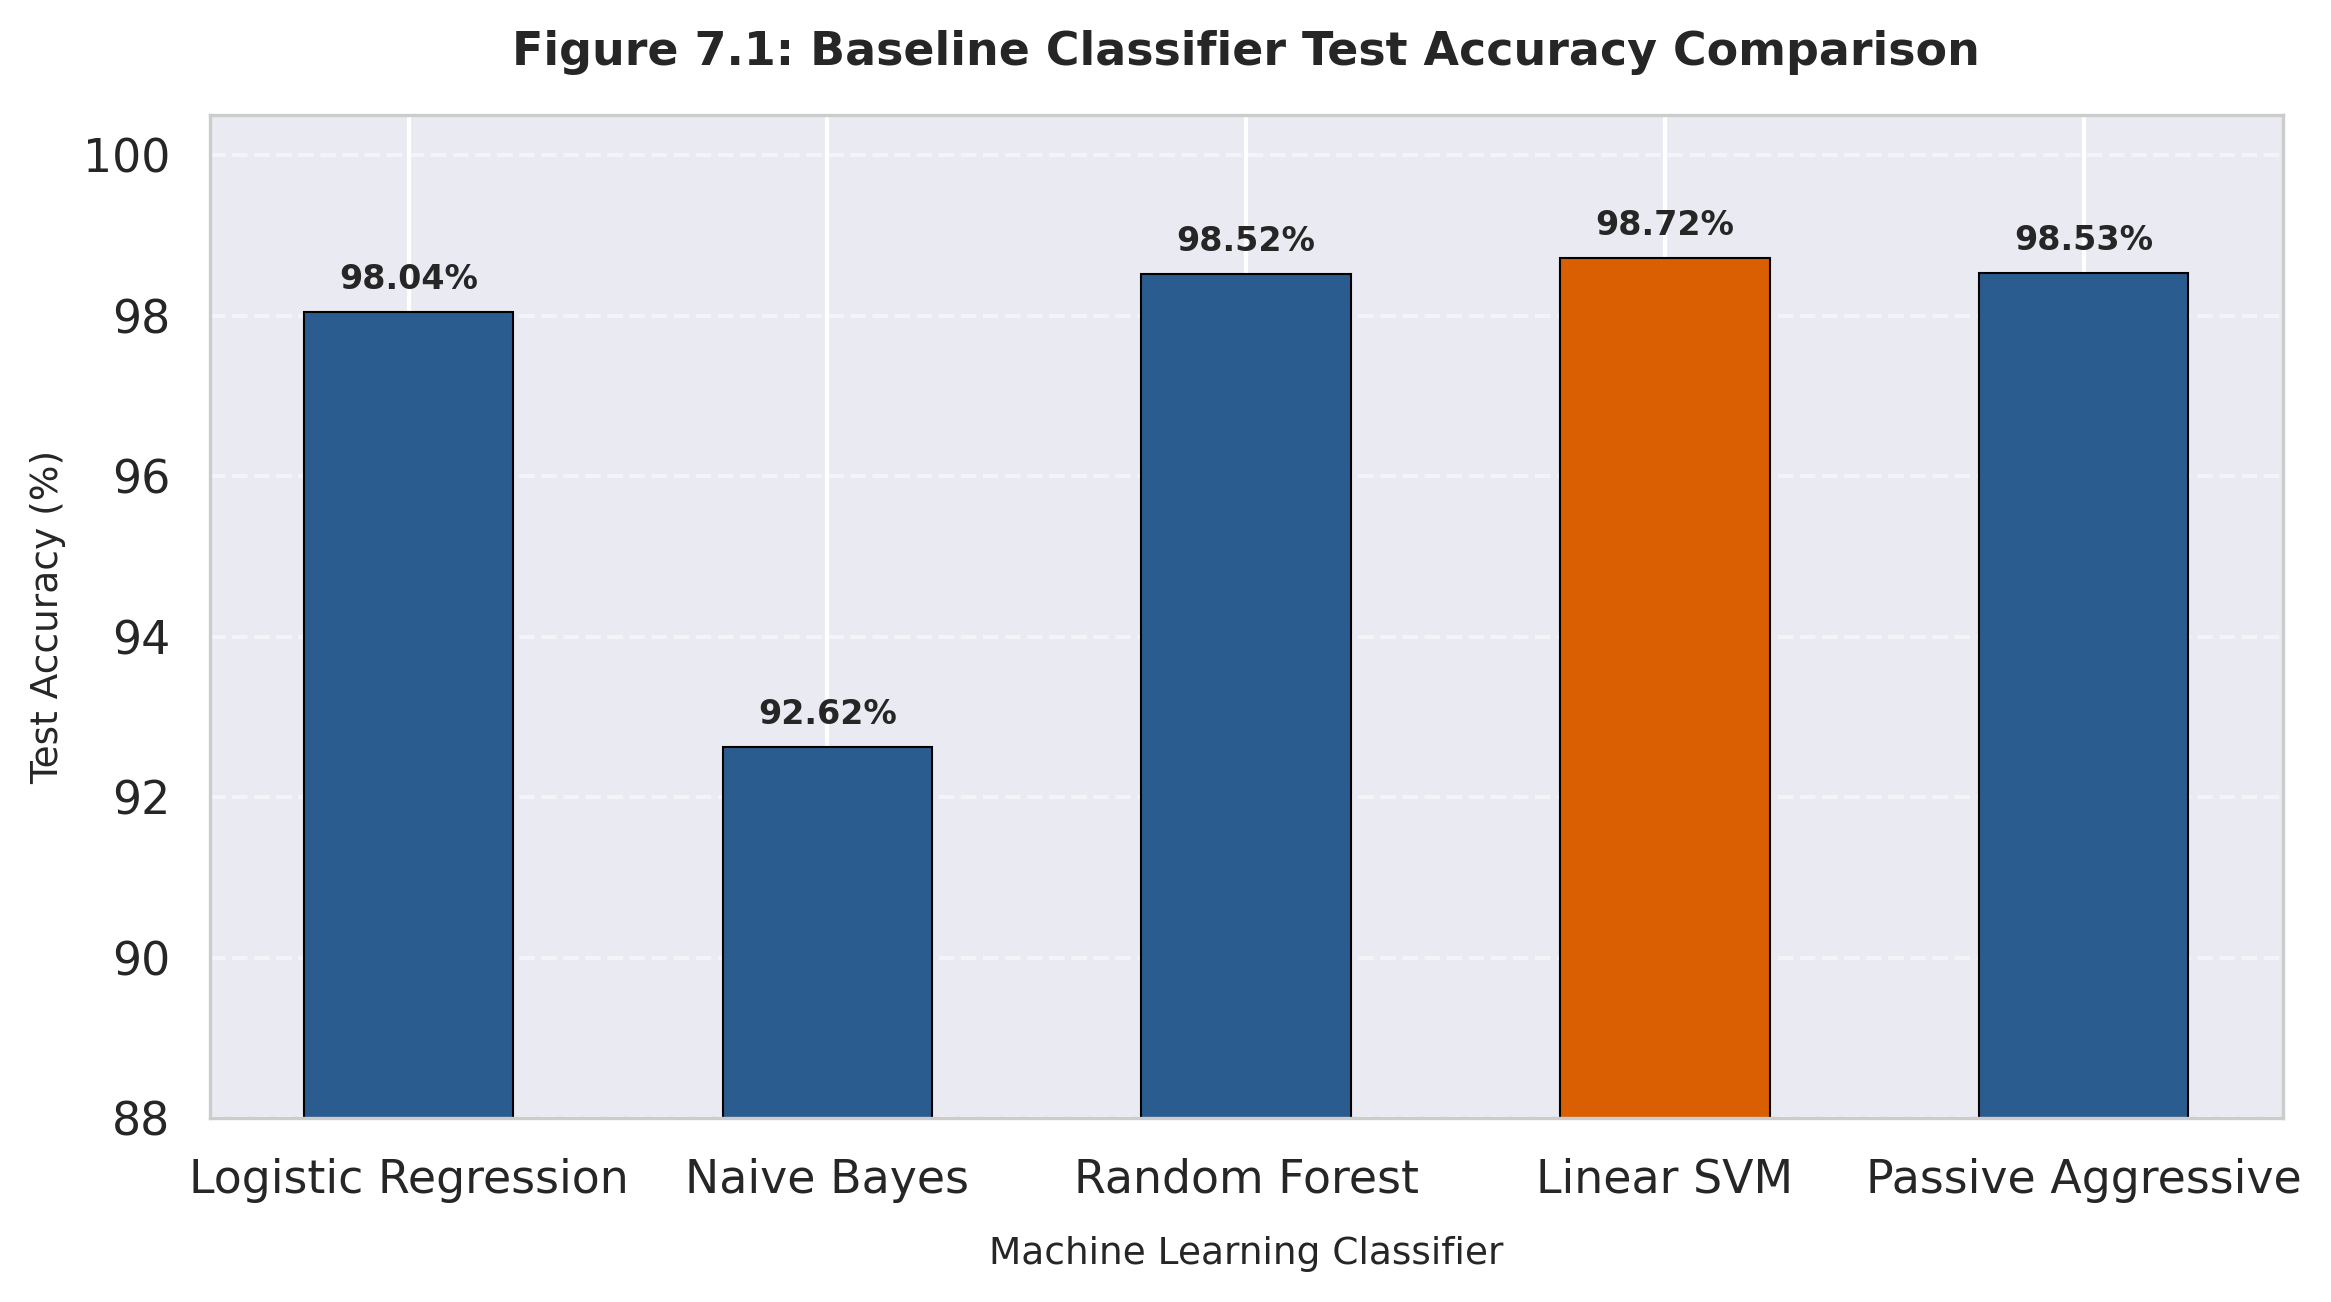

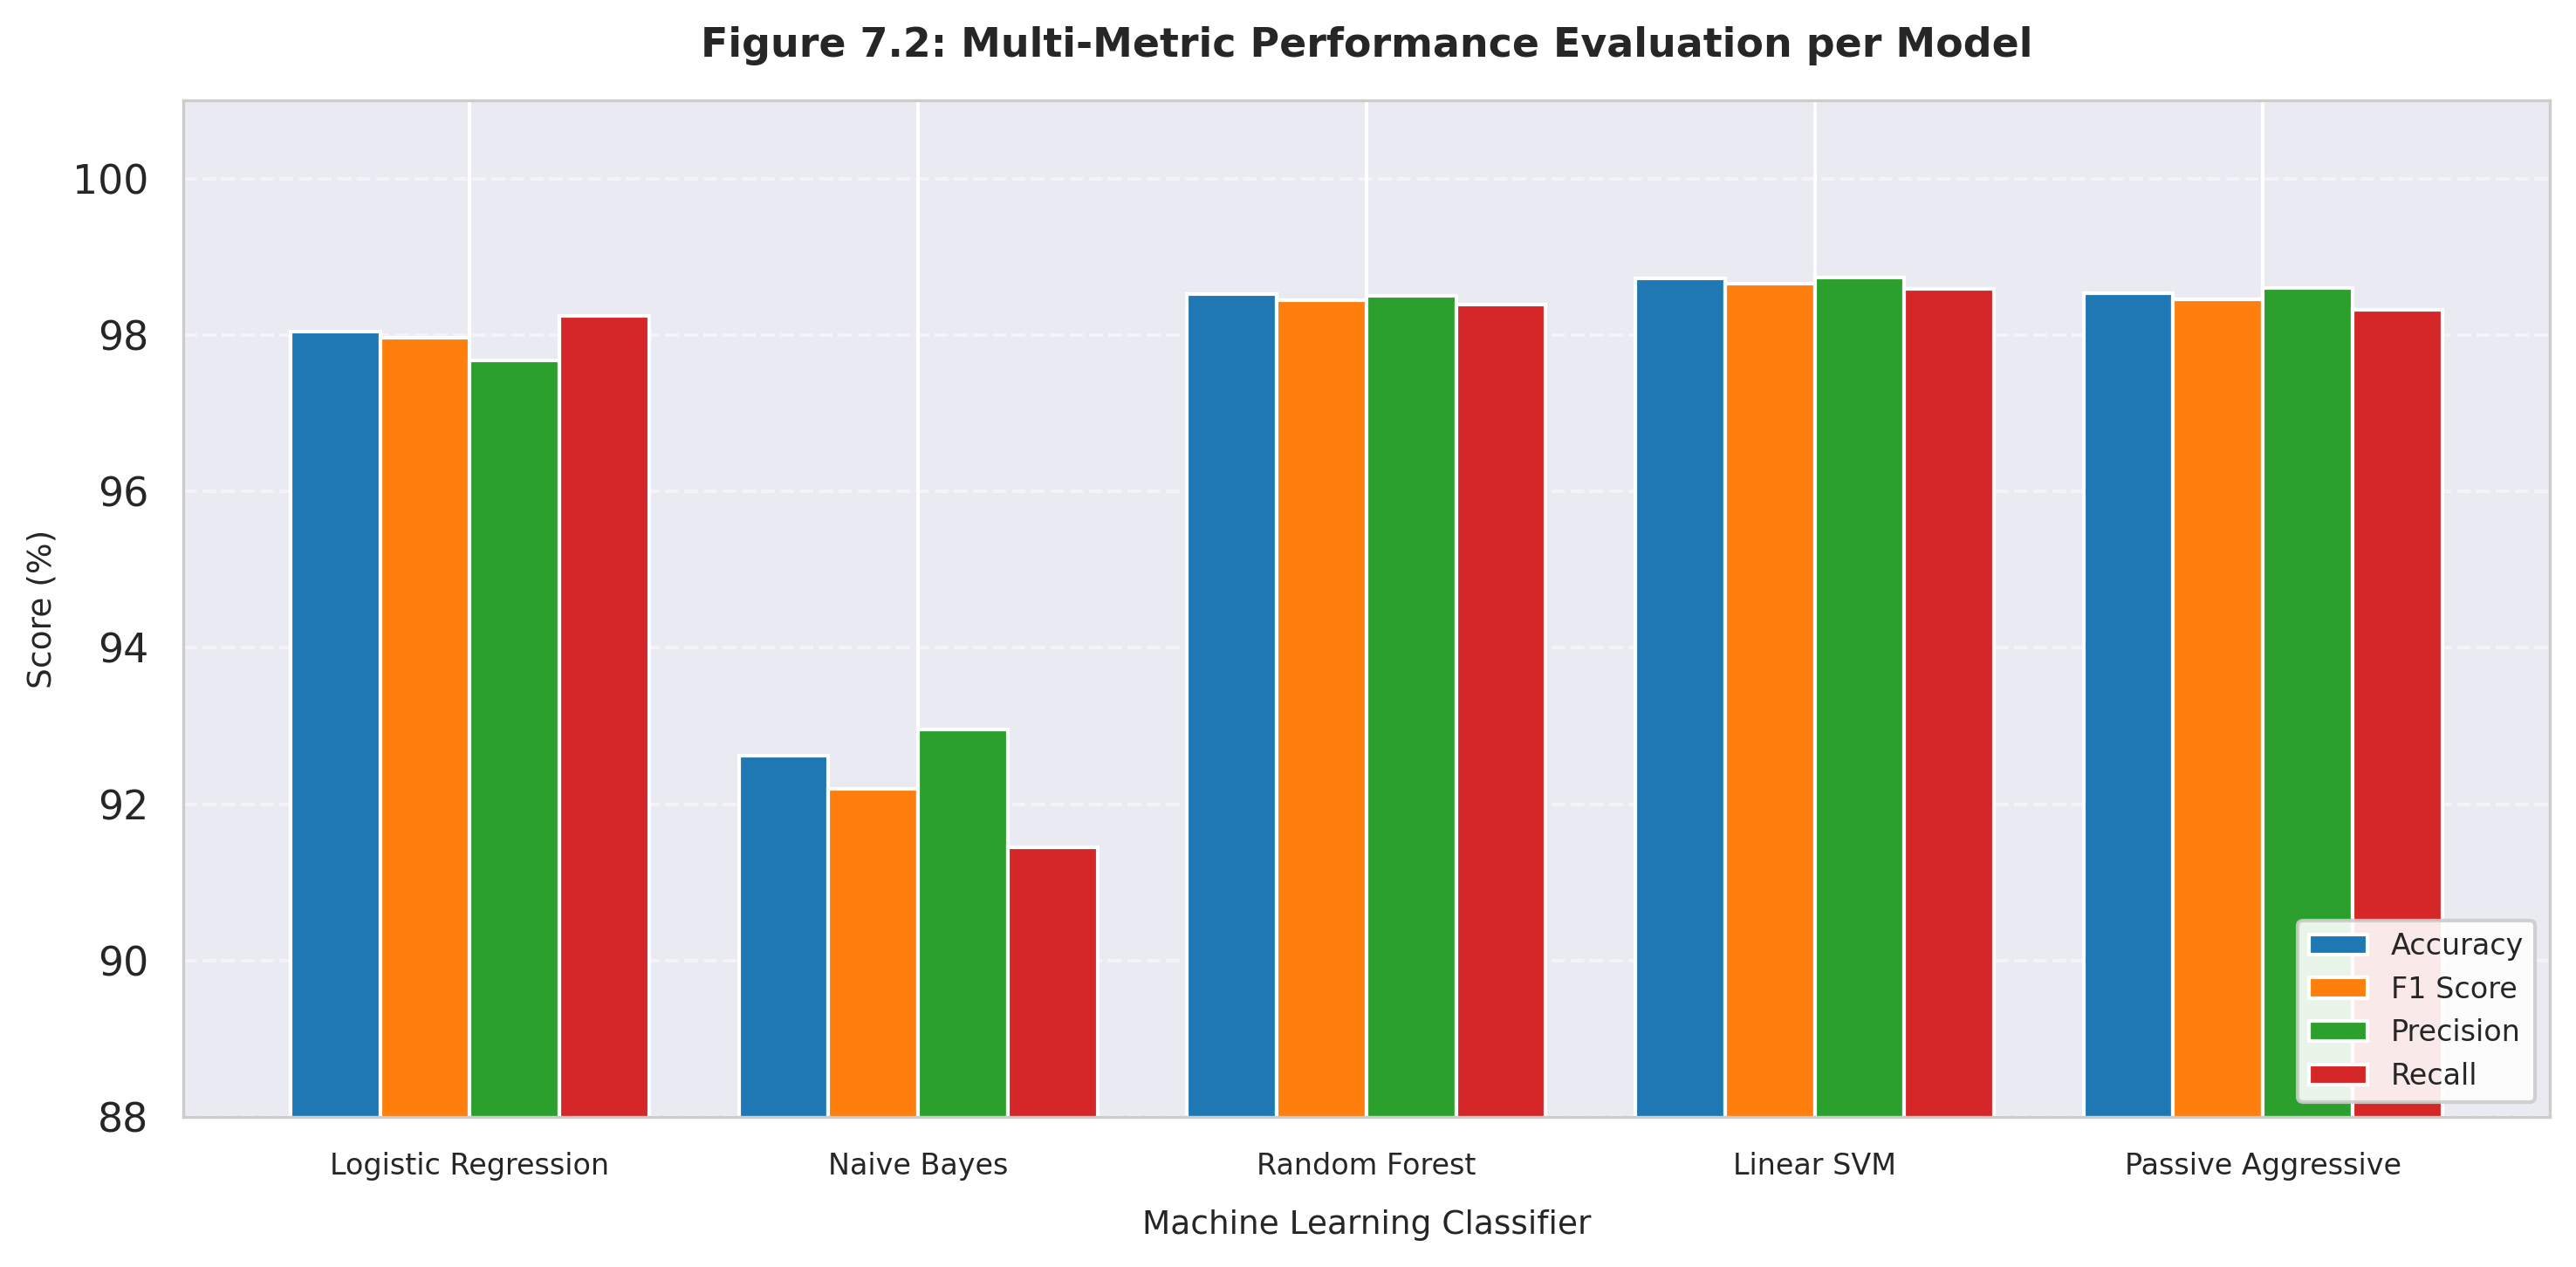

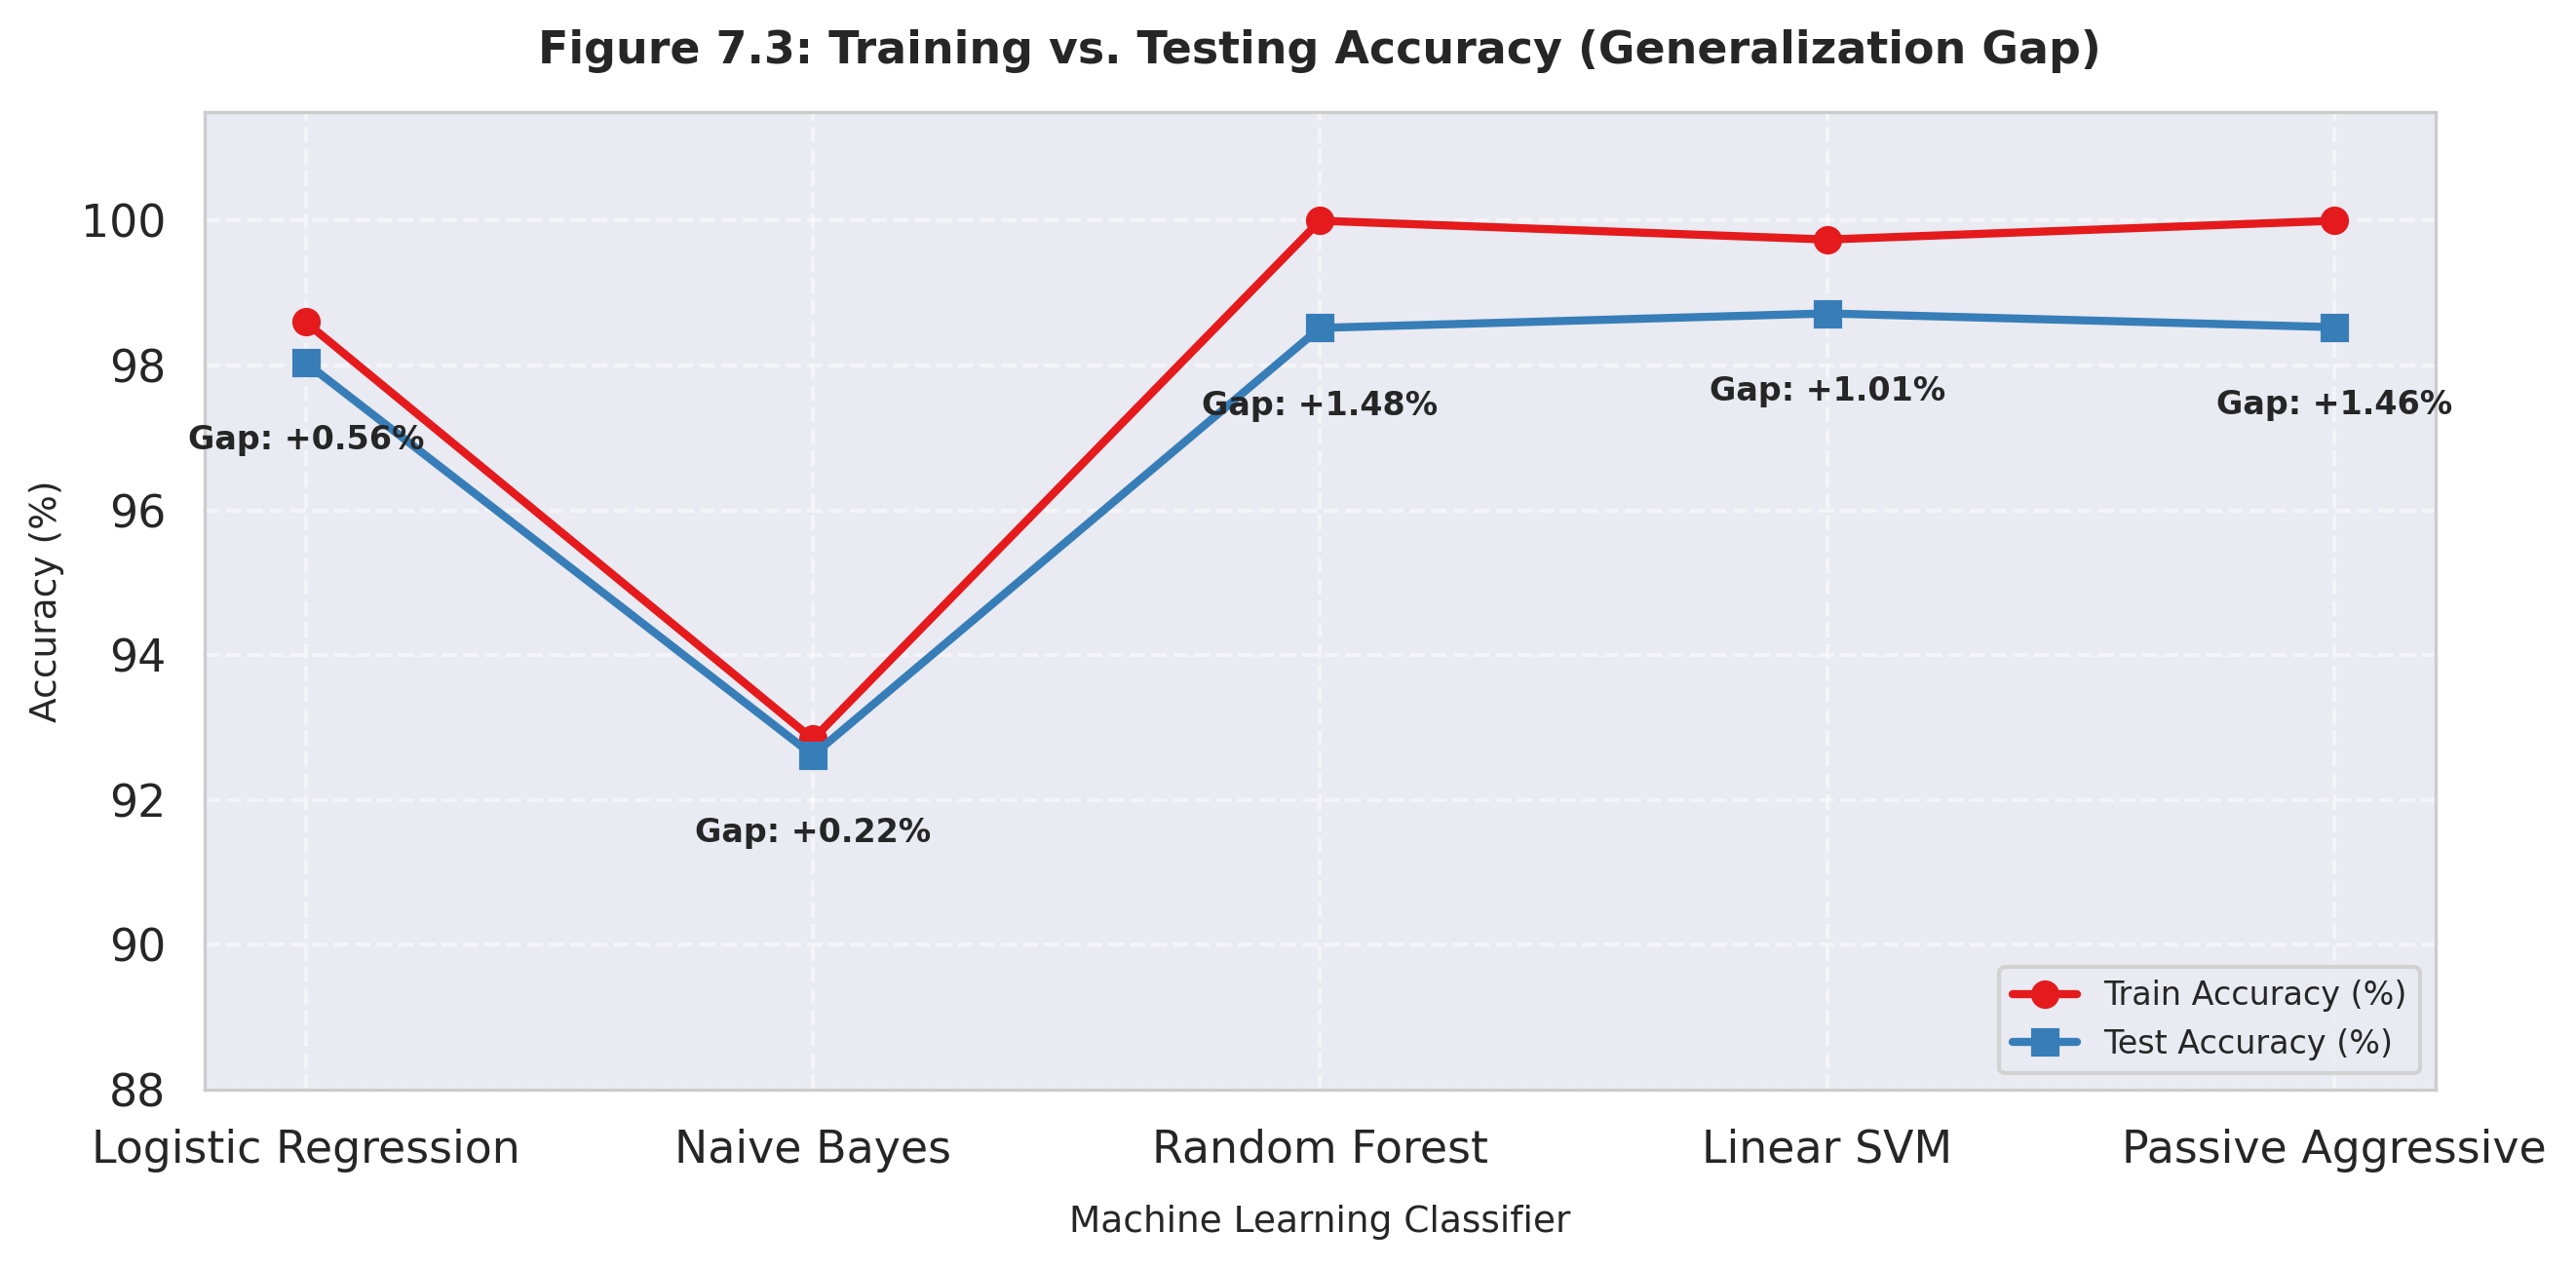

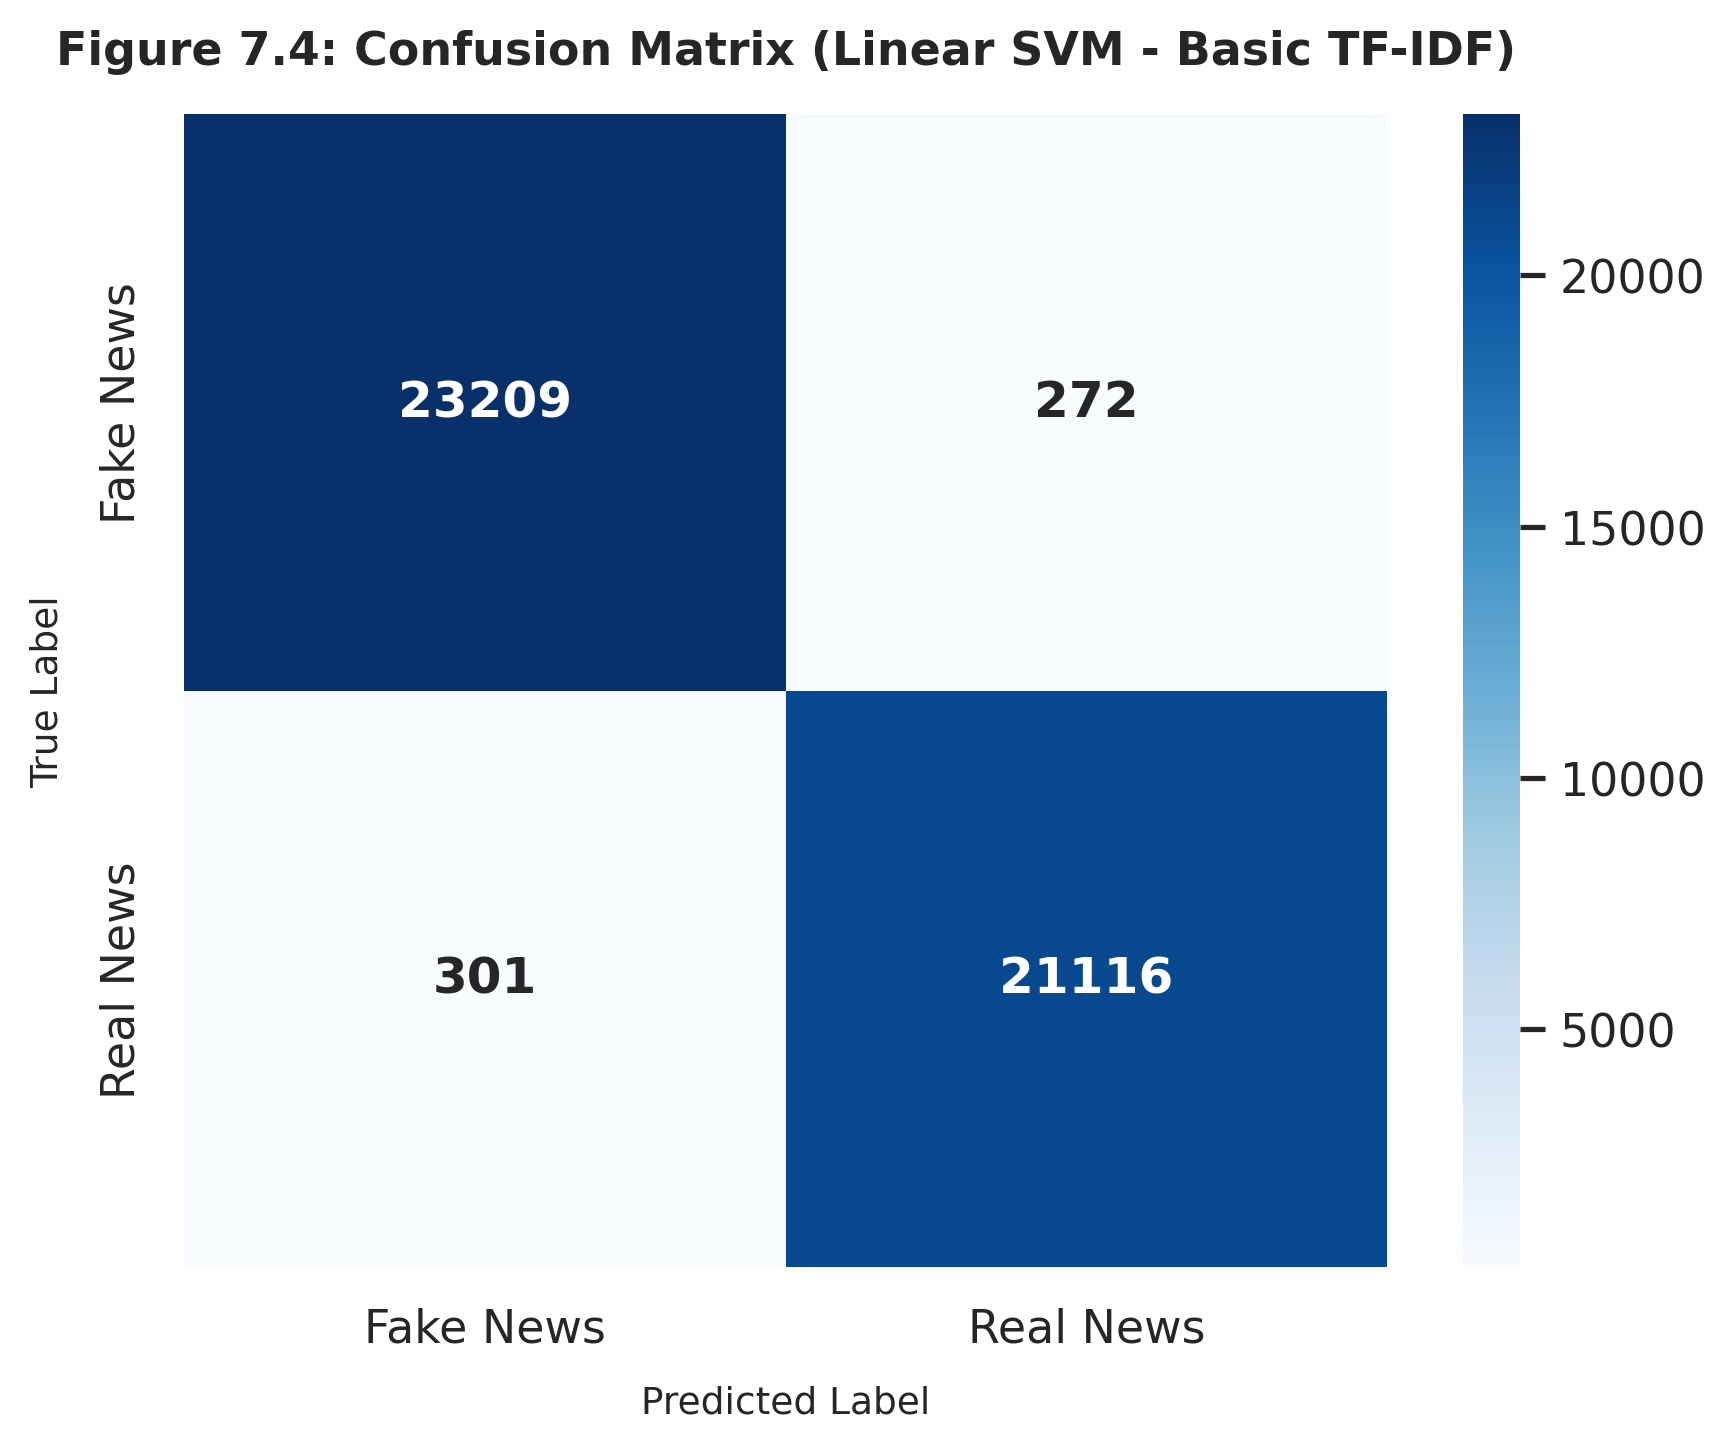

All 4 thesis figures successfully generated and saved to working directory!


In [29]:
# ==============================================================================
# GENERATE ALL THESIS FIGURES (BASIC TF-IDF BASELINE + CONFUSION MATRIX)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
import pandas as pd

# Define evaluation results as a DataFrame
data = {
    "Classifier Model": ["Logistic Regression", "Linear SVM", "Passive Aggressive", "Multinomial Naive Bayes", "Random Forest"],
    "Accuracy (%)": [98.04, 98.72, 98.53, 92.62, 98.52],
    "F1 Score (%)": [97.96, 98.66, 98.46, 92.20, 98.45],
    "Precision (%)": [97.67, 98.73, 98.60, 92.96, 98.50],
    "Recall (%)": [98.24, 98.59, 98.32, 91.45, 98.39],
    "Train Accuracy (%)": [98.60, 99.74, 100.00, 92.84, 100.00],
    "Gap (%)": ["+0.56", "+1.01", "+1.46", "+0.22", "+1.48"],
    "Verdict": ["Good fit", "Good fit", "Good fit", "Good fit", "Good fit"]
}

df_results = pd.DataFrame(data)

# Display table output directly in Jupyter Notebook / console
print(df_results.to_string(index=False))

# Global figure formatting styles
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Data extracted from 5-Fold Cross-Validation results
models = ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'Linear SVM', 'Passive Aggressive']
accuracy = [98.04, 92.62, 98.52, 98.72, 98.53]
f1_score = [97.96, 92.20, 98.45, 98.66, 98.46]
precision = [97.67, 92.96, 98.50, 98.73, 98.60]
recall = [98.24, 91.45, 98.39, 98.59, 98.32]
train_acc = [98.60, 92.84, 100.00, 99.74, 100.00]
gap = [0.56, 0.22, 1.48, 1.01, 1.46]

# ------------------------------------------------------------------------------
# FIGURE 7.1: Model Accuracy Comparison
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 4.5), dpi=300)
colors = ['#2b5c8f' if x < max(accuracy) else '#d95f02' for x in accuracy]
bars = plt.bar(models, accuracy, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

plt.ylim(88, 100.5)
plt.title('Figure 7.1: Baseline Classifier Test Accuracy Comparison', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Machine Learning Classifier', fontsize=9, labelpad=8)
plt.ylabel('Test Accuracy (%)', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.2, f'{height:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_1_accuracy.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 7.2: Multi-Metric Performance Evaluation
# ------------------------------------------------------------------------------
x = np.arange(len(models))
width = 0.20

plt.figure(figsize=(10, 5), dpi=300)
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='#1f77b4')
plt.bar(x - 0.5*width, f1_score, width, label='F1 Score', color='#ff7f0e')
plt.bar(x + 0.5*width, precision, width, label='Precision', color='#2ca02c')
plt.bar(x + 1.5*width, recall, width, label='Recall', color='#d62728')

plt.ylim(88, 101)
plt.title('Figure 7.2: Multi-Metric Performance Evaluation per Model', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Machine Learning Classifier', fontsize=9, labelpad=8)
plt.ylabel('Score (%)', fontsize=9)
plt.xticks(x, models, fontsize=8)
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig7_2_metrics.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 7.3: Training vs. Testing Accuracy (Generalization Gap)
# ------------------------------------------------------------------------------
plt.figure(figsize=(9, 4.5), dpi=300)
plt.plot(models, train_acc, marker='o', linewidth=2, color='#e41a1c', label='Train Accuracy (%)')
plt.plot(models, accuracy, marker='s', linewidth=2, color='#377eb8', label='Test Accuracy (%)')

plt.ylim(88, 101.5)
plt.title('Figure 7.3: Training vs. Testing Accuracy (Generalization Gap)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Machine Learning Classifier', fontsize=9, labelpad=8)
plt.ylabel('Accuracy (%)', fontsize=9)
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5)

for i, txt in enumerate(gap):
    plt.annotate(f'Gap: +{txt:.2f}%', (models[i], accuracy[i] - 1.2), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_3_gap.png', dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# FIGURE 7.4: Confusion Matrix (Linear SVM)
# ------------------------------------------------------------------------------
# Generate out-of-fold cross-validation predictions for Linear SVM
y_pred = cross_val_predict(base_models["SVM"], X, y, cv=cv5, n_jobs=1)

# Compute confusion matrix
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5), dpi=300)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=['Fake News', 'Real News'],
    yticklabels=['Fake News', 'Real News'],
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title('Figure 7.4: Confusion Matrix (Linear SVM - Basic TF-IDF)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', fontsize=9, labelpad=8)
plt.ylabel('True Label', fontsize=9, labelpad=8)

plt.tight_layout()
plt.savefig('fig7_4_confusion_matrix.png', dpi=300)
plt.show()

print("All 4 thesis figures successfully generated and saved to working directory!")

## ANALYSIS 2: FEATURE FUSION (TF-IDF + Stylometric Features)

### STEP 9: Extract Stylometric Features

 Section 9.1: Stylometric Feature Extraction on Raw Corpus

#Documentation

To ensure the integrity of structural writing indicators, stylometric feature extraction is performed exclusively on the **raw, uncleaned dataset (`'article'` column)** prior to any text preprocessing, tokenization, or lowercasing. 

### Why Extraction on the Raw Dataset is Critical:
1. **Preservation of Case Sensitivity**: Converting text to lowercase completely destroys uppercase tracking. Extracting `capital_count` from raw text ensures accurate measurement of capitalization ratios and author emphasis.
2. **Punctuation Integrity**: Standard text cleaning pipelines frequently strip punctuation marks. Preserving the raw source text allows accurate counting of exclamation marks (`!`) and question marks (`?`), which serve as strong indicators of sensationalist or emotional journalism.
3. **Accurate Length Metrics**: Exact character counts and word lengths rely on original spacing and punctuation bounds.

### Extracted Stylometric Attributes:
* **Character Count (`char_count`)**: Total character length of the raw article.
* **Word Count (`word_count`)**: Total word count based on whitespace separation.
* **Exclamation Mark Count (`exclaim_count`)**: Total frequency of `!` characters.
* **Question Mark Count (`question_count`)**: Total frequency of `?` characters.
* **Capitalization Ratio (`capital_ratio`)**: Proportion of uppercase letters relative to total character length.
* **Average Word Length (`avg_word_length`)**: Mean character length per word.

In [30]:
# ==============================================================================
# STEP 9A: EXTRACT STYLOMETRIC FEATURES FROM RAW 'article' COLUMN
# ==============================================================================
import pandas as pd
import numpy as np

print("=== STARTING STEP 9A: RAW STYLOMETRIC EXTRACTION ===")

# Verify 'article' column exists in the original dataset
if 'article' not in df.columns:
    raise KeyError("Column 'article' not found in your dataset columns: " + str(list(df.columns)))

# Extract structural and stylistic features directly from the raw 'article' text
char_count = df['article'].astype(str).str.len().fillna(0)
word_count = df['article'].astype(str).str.split().str.len().fillna(0)
exclaim_count = df['article'].astype(str).str.count('!')
question_count = df['article'].astype(str).str.count(r'\?')
capital_count = df['article'].astype(str).str.findall(r'[A-Z]').str.len().fillna(0)

# Compile into a structured DataFrame
stylometric_df = pd.DataFrame({
    'char_count': char_count,
    'word_count': word_count,
    'exclaim_count': exclaim_count,
    'question_count': question_count,
    'capital_ratio': capital_count / (char_count + 1),
    'avg_word_length': char_count / (word_count + 1)
}, dtype=np.float32)

print("Raw stylometric features successfully extracted from the original 'article' column.")
print(stylometric_df.head().to_string())

=== STARTING STEP 9A: RAW STYLOMETRIC EXTRACTION ===


KeyError: "Column 'article' not found in your dataset columns: ['content', 'label', 'content_debiased', 'clean_content']"

### Feature ScalingNormalizes raw stylometric features (character counts, word counts, punctuation frequencies, and capitalization ratios) into a uniform range of $[0, 1]$ using MinMaxScaler to prevent large numerical scales from dominating the sparse TF-IDF vectors during model fusion.

In [ ]:
# ==============================================================================
# STEP 9B: NORMALIZE STYLOMETRIC FEATURES
# ==============================================================================
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

print("=== STARTING STEP 9B: STYLOMETRIC SCALING ===")

# Initialize and fit MinMaxScaler on the raw stylometric DataFrame
scaler = MinMaxScaler()
stylometric_scaled = scaler.fit_transform(stylometric_df)

# Convert to DataFrame for validation review
df_style_scaled = pd.DataFrame(stylometric_scaled, columns=stylometric_df.columns)

print("Stylometric feature scaling completed successfully.")
print(df_style_scaled.head().to_string())
print(f"\nScaled Matrix Shape: {stylometric_scaled.shape}")

=== STARTING STEP 9B: STYLOMETRIC SCALING ===
Stylometric feature scaling completed successfully.
   char_count  word_count  exclaim_count  question_count  capital_ratio  avg_word_length
0    0.979167      0.8125            0.0             0.0       0.562452         0.643732
1    0.802083      0.5000            0.0             0.0       0.690277         0.940031
2    0.947917      0.6875            0.0             0.0       0.583356         0.810575
3    0.645833      0.5000            0.0             0.0       0.028460         0.666959
4    0.729167      0.6250            0.0             0.0       0.750341         0.575935

Scaled Matrix Shape: (80, 6)


### Combines the sparse TF-IDF word feature matrix with the scaled dense stylometric features into a unified feature matrix (X_fused) using scipy's sparse horizontal stacking.

### To ensure a fair and scientifically valid comparison, both the baseline and fused models use the exact same TF-IDF parameters (max_features=500 and stop_words='english').
The final fused feature matrix combines the 500 word-frequency columns with 6 normalized stylometric features, resulting in a unified 506-dimensional space.
This guarantees that any performance differences are driven entirely by the added stylometric features rather than text configuration discrepancies.

In [ ]:
# ==============================================================================
# STEP 10: CORRECTED EXPLICIT PARITY (max_features=500)
# ==============================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
import pandas as pd

print("=== STARTING STEP 10: CORRECTED 500-FEATURE FUSION ===")

# Explicitly set max_features to 500 to match your baseline
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X = vectorizer.fit_transform(df['article'].astype(str))

# Convert scaled stylometric array to sparse CSR format
style_sparse = csr_matrix(stylometric_scaled)

# Horizontally stack sparse TF-IDF and sparse stylometric matrices
X_fused = hstack([X.tocsr(), style_sparse]).tocsr()

print("Feature fusion completed successfully!")
print(f"TF-IDF Shape:        {X.shape}")       # Should be (80, 500) or less
print(f"Stylometric Shape:   {style_sparse.shape}") # Should be (80, 6)
print(f"Unified Fused Shape: {X_fused.shape}")   # Should be (80, 506) or less

=== STARTING STEP 10: CORRECTED 500-FEATURE FUSION ===
Feature fusion completed successfully!
TF-IDF Shape:        (80, 500)
Stylometric Shape:   (80, 6)
Unified Fused Shape: (80, 506)


### Evaluating the Fused Feature Models

Now that the feature fusion is complete (X_fused with shape (N, 506)), the next step is to evaluate your five classifiers (Logistic Regression, Linear SVM, Naive Bayes, Random Forest, and Passive Aggressive) on this new combined feature space using the exact same 5-fold cross-validation setup.

After running this evaluation, you will compare the performance metrics (Accuracy, F1 Score, Precision, and Recall) against your baseline results to measure the impact of adding stylometric features.

In [ ]:
# ==============================================================================
# COMPLETE END-TO-END PIPELINE (Sequential Execution: n_jobs=1)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=== 1. DETECTING COLUMNS & EXTRACTING STYLOMETRIC FEATURES ===")
text_col = 'clean_content' if 'clean_content' in df.columns else ('article' if 'article' in df.columns else df.columns[0])
target_col = 'expected_label' if 'expected_label' in df.columns else 'label'

print(f"Using text column: '{text_col}'")
print(f"Using target column: '{target_col}'")

# Extract the 6 normalized stylometric features
style_df = pd.DataFrame()
style_df['char_count'] = df[text_col].astype(str).apply(len)
style_df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))
style_df['exclamation'] = df[text_col].astype(str).apply(lambda x: x.count('!'))
style_df['question'] = df[text_col].astype(str).apply(lambda x: x.count('?'))
style_df['cap_ratio'] = df[text_col].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
style_df['avg_word_len'] = style_df['char_count'] / (style_df['word_count'] + 1)

scaler = MinMaxScaler()
stylometric_scaled = scaler.fit_transform(style_df)

print("=== 2. VECTORIZATION & FEATURE FUSION ===")
vectorizer = TfidfVectorizer(max_features=500, stop_words='english')
X = vectorizer.fit_transform(df[text_col].astype(str))
y = df[target_col].values

style_sparse = csr_matrix(stylometric_scaled)
X_fused = hstack([X.tocsr(), style_sparse]).tocsr()
print(f"Fused Matrix Shape: {X_fused.shape}")

# Define models
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(max_iter=1000, random_state=42, dual=False),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000, random_state=42)
}

print("\n=== 3. RUNNING 5-FOLD CROSS-VALIDATION (n_jobs=1) ===")
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fused_results = {}

for name, model in base_models.items():
    print(f"Evaluating {name}...")
    scores = cross_validate(
        model, X_fused, y, cv=cv5,
        scoring=["accuracy", "f1", "precision", "recall"],
        return_train_score=True, n_jobs=1
    )
    test_acc = scores["test_accuracy"].mean() * 100
    fused_results[name] = {"Accuracy": round(test_acc, 2)}

print("\n=== FUSED MODEL RESULTS ===")
print(pd.DataFrame(fused_results).T)

print("\n=== 4. GENERATING CONFUSION MATRICES (FIGURE 4.3) ===")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(base_models.items()):
    y_pred = cross_val_predict(model, X_fused, y, cv=cv5, n_jobs=1)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"Fused: {name}")

if len(base_models) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()
print("Pipeline completed successfully!")

=== 1. DETECTING COLUMNS & EXTRACTING STYLOMETRIC FEATURES ===
Using text column: 'clean_content'
Using target column: 'label'
